In [2]:
import re
import pandas as pd

# Load and parse raw text (building on your existing code)
with open("MeandRuby.txt", "r", encoding="utf-8") as f:
    lines = [line.strip() for line in f if line.strip()]

parsed_data = []
for line in lines:
    if " - " in line:
        parsed_data.append(line)
    elif parsed_data:
        parsed_data[-1] += " " + line

df = pd.DataFrame(parsed_data, columns=["RawText"])
df[["Date_Time", "Message_Body"]] = df["RawText"].str.split(" - ", n=1, expand=True)
df[["Date", "Time"]] = df["Date_Time"].str.split(r",\s*|\s+", n=1, expand=True, regex=True)
df[["Name", "Chat"]] = df["Message_Body"].str.split(": ", n=1, expand=True)

# Drop system notifications or empty rows for cleaner analysis
df = df.dropna(subset=["Name", "Chat"])
df = df[~df["Chat"].str.contains("Messages and calls are end-to-end encrypted", na=False)]

In [ ]:
#!pip install textblob seaborn matplotlib

In [3]:
from textblob import TextBlob

# Function to get polarity (-1 to 1)
def get_sentiment(text):
    return TextBlob(str(text)).sentiment.polarity

df["Sentiment_Score"] = df["Chat"].apply(get_sentiment)

# Categorize sentiment
def classify_sentiment(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment_Category"] = df["Sentiment_Score"].apply(classify_sentiment)
print(df["Sentiment_Category"].value_counts())

Sentiment_Category
Neutral     513
Positive    271
Negative     16
Name: count, dtype: int64


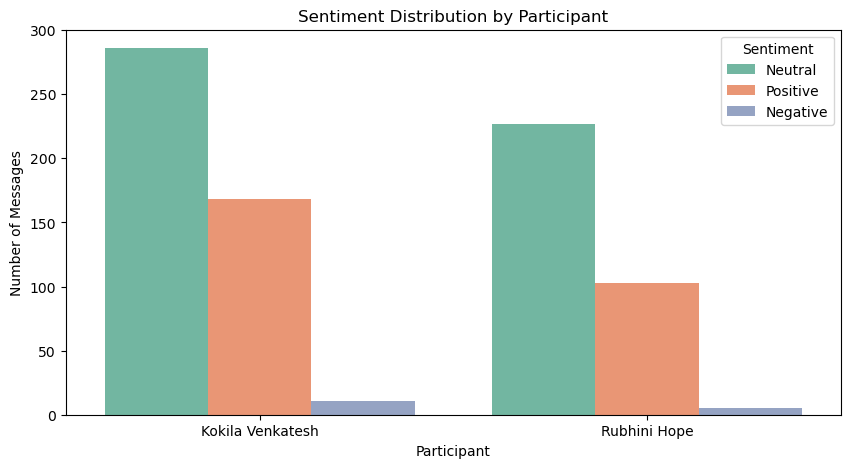

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Name', hue='Sentiment_Category', palette='Set2')
plt.title('Sentiment Distribution by Participant')
plt.xlabel('Participant')
plt.ylabel('Number of Messages')
plt.legend(title='Sentiment')
plt.show()